<a href="https://colab.research.google.com/github/seulkong/karpathy_study/blob/main/chapter4_compare_two_groups_ipynb%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 4: Are the Measurements Different Between Two Groups?

**Genomics Statistics Tutorial - Python**

In this notebook, you'll learn:
- **Understand parametric vs non-parametric approaches**
- **Visualize data before testing (descriptive statistics)**
- Check critical assumptions (normality, homogeneity)
- Choose between t-test and Mann-Whitney U test
- Interpret statistical results in biological context

---

## Setup: Install and Load Packages

In [ ]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, ttest_ind, mannwhitneyu
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✓ Packages loaded successfully!")

✓ Packages loaded successfully!


---

## Biological Question

You're studying autism spectrum disorder (ASD). You've measured gene expression levels from two groups:
- **Case group:** ASD patients (n=30)
- **Control group:** Healthy individuals (n=30)

**The key question: "Is gene expression different between Case and Control groups?"**

Another example: In single-cell RNA-seq analysis, you identified Cluster A and Cluster B. You want to know if these clusters have different inflammatory scores.

This "two-group comparison" is one of the most common questions in biology.

---

## Part 1: Look at the Data First (Descriptive Statistics)

**Never start with statistical tests!**

Always visualize your data first. Looking at plots helps you:
- Understand the distribution shape
- Spot outliers
- See if groups actually look different
- Decide which statistical test to use

This is called **descriptive statistics** - describing what you see in the data.

### Generate Sample Data

Let's create example gene expression data.

In [ ]:
# Set seed for reproducibility
np.random.seed(123)

# Case group (n=30): higher expression
case_expression = np.random.normal(loc=8.5, scale=1.2, size=30)

# Control group (n=30): lower expression
control_expression = np.random.normal(loc=7.8, scale=1.0, size=30)

# Combine into a DataFrame
data = pd.DataFrame({
    'expression': np.concatenate([case_expression, control_expression]),
    'group': ['Case']*30 + ['Control']*30
})

# Show first few rows
print("Sample Data:")
print(data.head(10))
print(f"\nTotal samples: {len(data)}")

Sample Data:
   expression group
0    7.197243  Case
1    9.696815  Case
2    8.839574  Case
3    6.692446  Case
4    7.805680  Case
5   10.481724  Case
6    5.587985  Case
7    7.985305  Case
8   10.019124  Case
9    7.459912  Case

Total samples: 60


### Visualization 1: Boxplot

Boxplots show you the distribution at a glance.

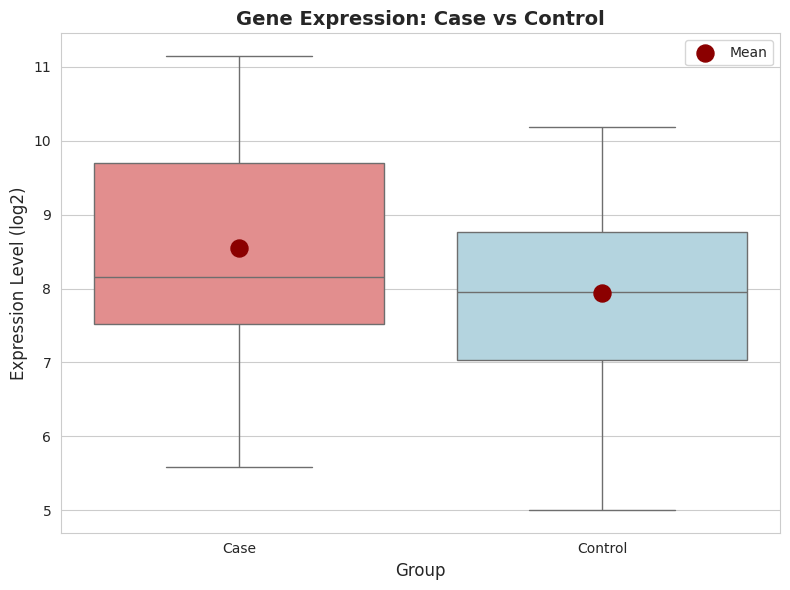


What to look for in a boxplot:
- Thick line inside box: Median
- Box boundaries: 25th and 75th percentiles
- Whiskers: Range of data
- Dots outside whiskers: Outliers
- Red dots (we added): Mean

Key question: Do the boxes overlap? If not, the groups likely differ.


In [ ]:
# Create boxplot
plt.figure(figsize=(8, 6))
box_plot = sns.boxplot(x='group', y='expression', data=data,
                       palette={'Case': 'lightcoral', 'Control': 'lightblue'})

# Add mean points
means = data.groupby('group')['expression'].mean()
positions = [0, 1]
plt.scatter(positions, means, color='darkred', s=150, zorder=3, label='Mean')

plt.title('Gene Expression: Case vs Control', fontsize=14, fontweight='bold')
plt.ylabel('Expression Level (log2)', fontsize=12)
plt.xlabel('Group', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

print("\nWhat to look for in a boxplot:")
print("- Thick line inside box: Median")
print("- Box boundaries: 25th and 75th percentiles")
print("- Whiskers: Range of data")
print("- Dots outside whiskers: Outliers")
print("- Red dots (we added): Mean")
print("\nKey question: Do the boxes overlap? If not, the groups likely differ.")

### Visualization 2: Histogram

Histograms show the shape of the distribution in detail.

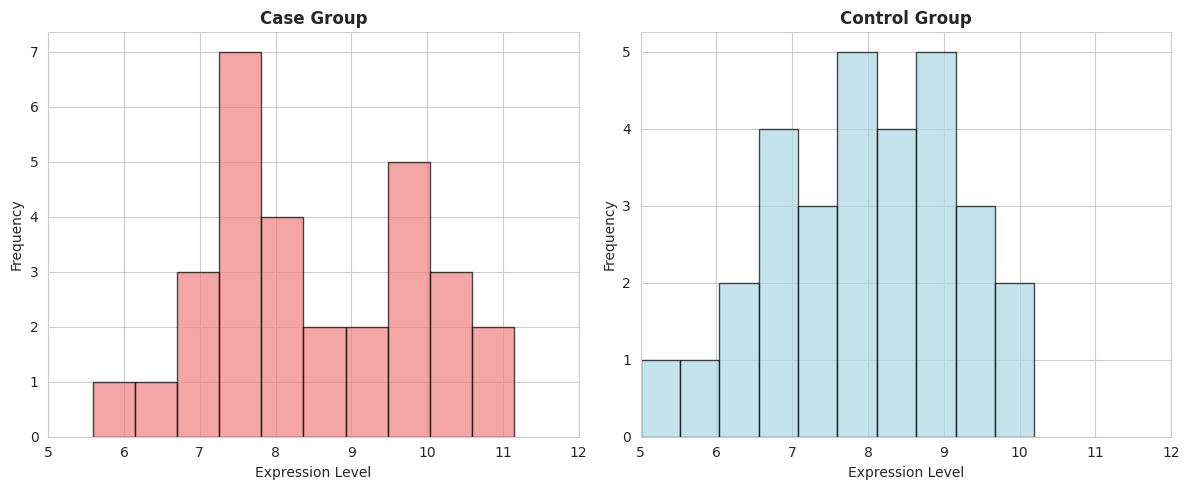


What to look for in histograms:
- Bell-shaped curve? → Likely normal distribution
- Skewed to one side? → Non-normal distribution
- Multiple peaks? → Might be mixing two populations
- Extreme values far from center? → Outliers present


In [ ]:
# Create side-by-side histograms
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Case group histogram
axes[0].hist(case_expression, bins=10, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0].set_title('Case Group', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Expression Level')
axes[0].set_ylabel('Frequency')
axes[0].set_xlim(5, 12)

# Control group histogram
axes[1].hist(control_expression, bins=10, color='lightblue', edgecolor='black', alpha=0.7)
axes[1].set_title('Control Group', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Expression Level')
axes[1].set_ylabel('Frequency')
axes[1].set_xlim(5, 12)

plt.tight_layout()
plt.show()

print("\nWhat to look for in histograms:")
print("- Bell-shaped curve? → Likely normal distribution")
print("- Skewed to one side? → Non-normal distribution")
print("- Multiple peaks? → Might be mixing two populations")
print("- Extreme values far from center? → Outliers present")

### Visualization 3: Q-Q Plot

Q-Q (Quantile-Quantile) plots are the best way to check if data follows a normal distribution.

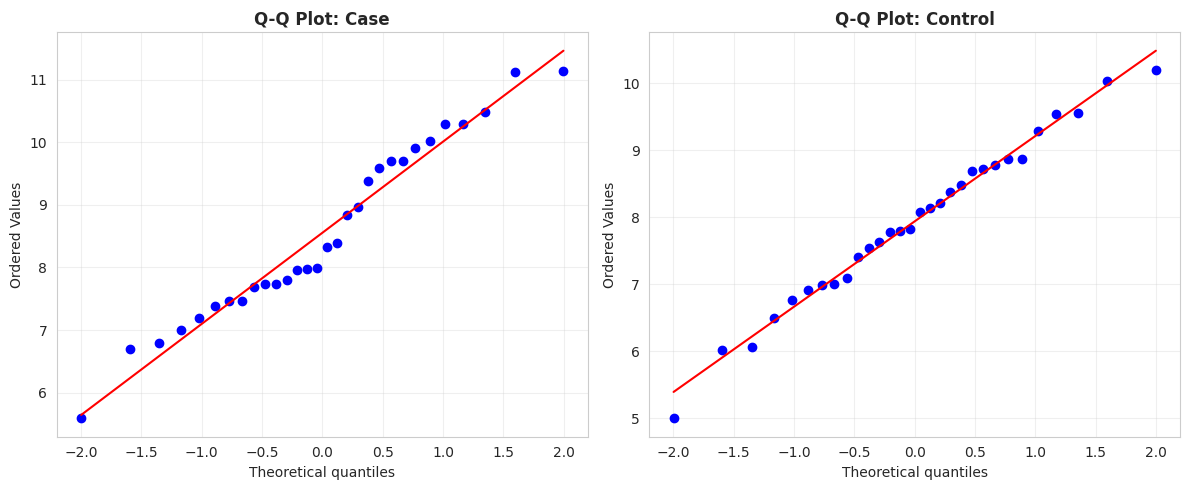


How to interpret Q-Q plots:

If data is normally distributed, points should fall along the red line.

- Points follow the line closely → Normal distribution ✓
- Points curve away at the ends → Heavy or light tails
- Points form an S-shape → Skewed distribution
- Points far from the line → Outliers or non-normal

Why does this matter? Because it determines which statistical test we should use!


In [ ]:
# Create Q-Q plots for both groups
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Case group Q-Q plot
stats.probplot(case_expression, dist="norm", plot=axes[0])
axes[0].set_title('Q-Q Plot: Case', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Control group Q-Q plot
stats.probplot(control_expression, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot: Control', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nHow to interpret Q-Q plots:")
print("\nIf data is normally distributed, points should fall along the red line.")
print("\n- Points follow the line closely → Normal distribution ✓")
print("- Points curve away at the ends → Heavy or light tails")
print("- Points form an S-shape → Skewed distribution")
print("- Points far from the line → Outliers or non-normal")
print("\nWhy does this matter? Because it determines which statistical test we should use!")

---

## Part 2: Understanding Parametric vs Non-Parametric Tests

### What is a "Parameter"?

A **parameter** is a numerical characteristic of a population. The most common parameters are:
- **Mean (μ):** Average value
- **Variance (σ²):** Measure of spread
- **Standard deviation (σ):** Square root of variance

### Parametric Tests

**Parametric tests make assumptions about population parameters.**

The most important assumption: **data follows a normal distribution**.

A normal distribution is defined by two parameters:
1. Mean (μ) - center of the curve
2. Standard deviation (σ) - width of the curve

**Examples of parametric tests:**
- T-test
- ANOVA
- Linear regression

**Advantages:**
- More powerful (better at detecting real differences)
- Familiar and widely used
- Can estimate effect sizes easily

**Disadvantages:**
- Requires normality assumption
- Sensitive to outliers
- May give wrong results if assumptions violated

### Non-Parametric Tests

**Non-parametric tests make NO assumptions about population parameters.**

They don't assume any specific distribution shape. Instead, they work with:
- **Ranks** (ordering of values)
- **Medians** (middle value)
- **Sign tests** (above/below threshold)

**Examples of non-parametric tests:**
- Mann-Whitney U test (= Wilcoxon rank-sum test)
- Kruskal-Wallis test
- Spearman correlation

**Advantages:**
- No normality assumption needed
- Works with any distribution
- Resistant to outliers
- Good for ordinal data (rankings)

**Disadvantages:**
- Less powerful than parametric tests (when data IS normal)
- Harder to interpret effect sizes
- Tests medians, not means

### Decision Tree: Which Test to Use?

```
Comparing two groups
│
├─ Is data normally distributed? (Check with Q-Q plot)
│   │
│   ├─ YES → Use T-test (Parametric)
│   │         • Statistic: t-statistic
│   │         • Assumptions: Normal distribution, independence
│   │         • Compares: Means
│   │         • Sensitive to: Outliers
│   │
│   └─ NO  → Use Mann-Whitney U test (Non-parametric)
│             • Statistic: U-statistic (based on ranks)
│             • Assumptions: Only independence
│             • Compares: Distributions (medians)
│             • Robust to: Outliers, skewed distributions
```

---

## Part 3: Checking Normality (Statistical Test)

### Shapiro-Wilk Test

In addition to visual inspection (Q-Q plot), we can use a statistical test.

**Shapiro-Wilk test:**
- **Null hypothesis (H₀):** Data is normally distributed
- **Alternative hypothesis (H₁):** Data is NOT normally distributed

**Interpretation:**
- **p-value > 0.05** → Cannot reject H₀ → Data appears normal ✓
- **p-value ≤ 0.05** → Reject H₀ → Data is likely non-normal

In [ ]:
# Shapiro-Wilk test for both groups
print("Shapiro-Wilk Test Results:")
print("="*52)

# Test Case group
stat_case, p_case = shapiro(case_expression)
print("\nCase Group:")
print(f"  W statistic: {stat_case:.4f}")
print(f"  P-value: {p_case:.4f}")

if p_case > 0.05:
    print("  → Data appears normally distributed (p > 0.05)")
    print("  → We can use parametric test (t-test)")
else:
    print("  → Data may NOT be normally distributed (p ≤ 0.05)")
    print("  → Consider non-parametric test (Mann-Whitney)")

# Test Control group
stat_control, p_control = shapiro(control_expression)
print("\nControl Group:")
print(f"  W statistic: {stat_control:.4f}")
print(f"  P-value: {p_control:.4f}")

if p_control > 0.05:
    print("  → Data appears normally distributed (p > 0.05)")
    print("  → We can use parametric test (t-test)")
else:
    print("  → Data may NOT be normally distributed (p ≤ 0.05)")
    print("  → Consider non-parametric test (Mann-Whitney)")

print("\n" + "="*52)
print("Important note: The Shapiro-Wilk test is sensitive to sample size:")
print("- Small samples: May not detect non-normality")
print("- Large samples: May detect trivial deviations from normality")
print("\nBest practice: Use BOTH Q-Q plots AND Shapiro-Wilk test together.")

Shapiro-Wilk Test Results:

Case Group:
  W statistic: 0.9621
  P-value: 0.3509
  → Data appears normally distributed (p > 0.05)
  → We can use parametric test (t-test)

Control Group:
  W statistic: 0.9875
  P-value: 0.9717
  → Data appears normally distributed (p > 0.05)
  → We can use parametric test (t-test)

Important note: The Shapiro-Wilk test is sensitive to sample size:
- Small samples: May not detect non-normality
- Large samples: May detect trivial deviations from normality

Best practice: Use BOTH Q-Q plots AND Shapiro-Wilk test together.


---

## Part 4: Parametric Approach - Independent T-Test

### When to use:
- Comparing means of two independent groups
- Data is approximately normally distributed
- No major outliers

### How it works:

The t-test calculates a **t-statistic**, which measures how different the two means are, relative to the variation in the data.

```
t = (mean₁ - mean₂) / SE(difference)

where SE = standard error of the difference
```

**Large |t|** → Groups are very different → Small p-value

**Small |t|** → Groups are similar → Large p-value

### Hypotheses:
- **Null hypothesis (H₀):** μ₁ = μ₂ (means are equal)
- **Alternative hypothesis (H₁):** μ₁ ≠ μ₂ (means are different)

### What is a p-value?

**P-value:** The probability of seeing data this extreme (or more extreme) if H₀ were true.

**Frequentist interpretation:**
- p-value is NOT the probability that H₀ is true
- It's the probability of the data, given H₀
- Small p-value (< 0.05) → Reject H₀
- Large p-value (≥ 0.05) → Fail to reject H₀

**Important:** p-value does NOT tell you the size or importance of the difference!

In [ ]:
# Perform independent t-test
print("\nIndependent T-Test")
print("="*52)

# Perform t-test
t_stat, p_value = ttest_ind(case_expression, control_expression)

# Calculate descriptive statistics
mean_case = np.mean(case_expression)
mean_control = np.mean(control_expression)
std_case = np.std(case_expression, ddof=1)
std_control = np.std(control_expression, ddof=1)
mean_diff = mean_case - mean_control

# Calculate effect size (Cohen's d)
pooled_std = np.sqrt((std_case**2 + std_control**2) / 2)
cohens_d = mean_diff / pooled_std

print("\n--- Summary ---")
print(f"Case mean: {mean_case:.2f} (SD: {std_case:.2f})")
print(f"Control mean: {mean_control:.2f} (SD: {std_control:.2f})")
print(f"Mean difference: {mean_diff:.2f}")

print("\n--- Test Statistic ---")
print(f"t-statistic: {t_stat:.4f}")

print("\n--- P-value (Hypothesis Testing) ---")
print(f"p-value: {p_value:.6f}")

if p_value < 0.05:
    print("→ Reject null hypothesis (p < 0.05)")
    print("→ The means are significantly different")
else:
    print("→ Fail to reject null hypothesis (p ≥ 0.05)")
    print("→ No significant difference detected")

print("\n--- Effect Size ---")
print(f"Cohen's d: {cohens_d:.4f}")
print("Interpretation: ", end="")
if abs(cohens_d) < 0.2:
    print("Very small effect")
elif abs(cohens_d) < 0.5:
    print("Small effect")
elif abs(cohens_d) < 0.8:
    print("Medium effect")
else:
    print("Large effect")


Independent T-Test

--- Summary ---
Case mean: 8.55 (SD: 1.42)
Control mean: 7.94 (SD: 1.23)
Mean difference: 0.61

--- Test Statistic ---
t-statistic: 1.7798

--- P-value (Hypothesis Testing) ---
p-value: 0.080342
→ Fail to reject null hypothesis (p ≥ 0.05)
→ No significant difference detected

--- Effect Size ---
Cohen's d: 0.4596
Interpretation: Small effect


### Key Concepts:

**1. Statistic (t-statistic):**
- A number calculated from your data
- Measures how different the groups are
- For t-test: measures difference in means relative to variability

**2. P-value (Hypothesis Testing):**
- Result of frequentist hypothesis testing
- Tests the null hypothesis (H₀: no difference)
- Threshold: Usually 0.05

**3. Effect Size (Cohen's d):**
- Measures the *magnitude* of difference
- Independent of sample size
- Guidelines: 0.2 (small), 0.5 (medium), 0.8 (large)

**Important distinction:**
- Statistical significance (p-value) ≠ Biological importance (effect size)
- You can have p < 0.05 with tiny effect (large sample)
- You can have large effect with p > 0.05 (small sample)

---

## Part 5: Non-Parametric Approach - Mann-Whitney U Test

### When to use:
- Data is NOT normally distributed
- Presence of outliers
- Small sample size
- Ordinal data (rankings)

### How it works:

Instead of comparing means, Mann-Whitney test:
1. **Ranks** all values from both groups together
2. Calculates sum of ranks for each group
3. Tests if rank sums are different

This makes it **robust to outliers** - an outlier just becomes the highest rank.

### Example:
```
Group A: 5, 7, 8, 100  →  Ranks: 1, 3, 4, 8  →  Sum = 16
Group B: 6, 9, 10, 11  →  Ranks: 2, 5, 6, 7  →  Sum = 20

Notice: The outlier (100) doesn't distort the test!
```

### Create Non-Normal Data for Demonstration

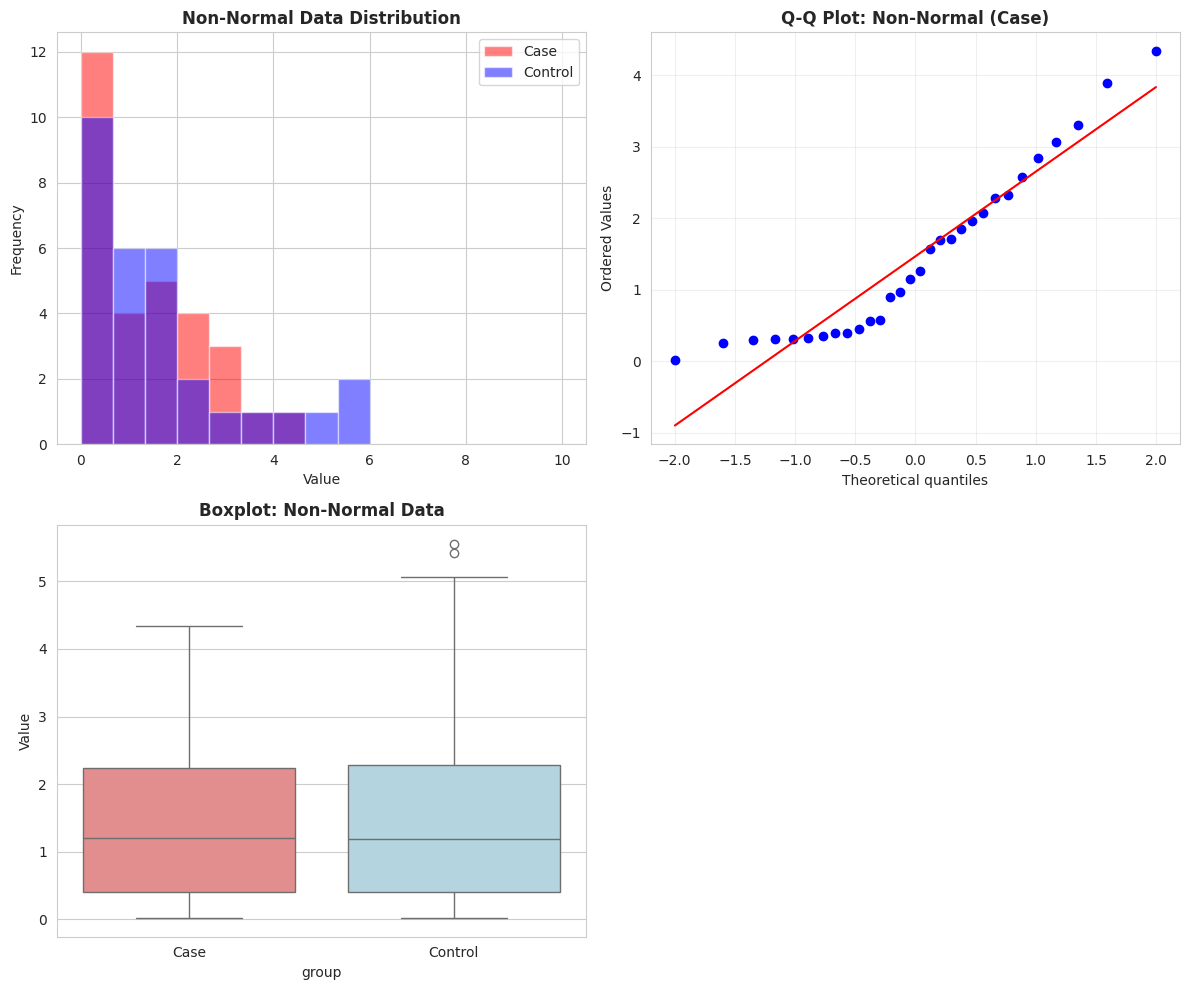


Shapiro-Wilk test p-value: 0.010506
→ This data is clearly NON-NORMAL!
→ We should use Mann-Whitney U test, NOT t-test


In [ ]:
# Generate non-normal data (exponential distribution)
np.random.seed(456)
nonnormal_case = np.random.exponential(scale=2, size=30)  # Mean = 2
nonnormal_control = np.random.exponential(scale=1.5, size=30)  # Mean = 1.5

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Histogram
axes[0, 0].hist(nonnormal_case, bins=15, alpha=0.5, color='red', label='Case', range=(0, 10))
axes[0, 0].hist(nonnormal_control, bins=15, alpha=0.5, color='blue', label='Control', range=(0, 10))
axes[0, 0].set_title('Non-Normal Data Distribution', fontweight='bold')
axes[0, 0].set_xlabel('Value')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()

# 2. Q-Q Plot - clearly shows non-normality
stats.probplot(nonnormal_case, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot: Non-Normal (Case)', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Boxplot
box_data = pd.DataFrame({
    'value': np.concatenate([nonnormal_case, nonnormal_control]),
    'group': ['Case']*30 + ['Control']*30
})
sns.boxplot(x='group', y='value', data=box_data, ax=axes[1, 0],
            palette={'Case': 'lightcoral', 'Control': 'lightblue'})
axes[1, 0].set_title('Boxplot: Non-Normal Data', fontweight='bold')
axes[1, 0].set_ylabel('Value')

# 4. Remove empty subplot
fig.delaxes(axes[1, 1])

plt.tight_layout()
plt.show()

# Shapiro test confirms non-normality
stat_nn, p_nn = shapiro(nonnormal_case)
print(f"\nShapiro-Wilk test p-value: {p_nn:.6f}")
print("→ This data is clearly NON-NORMAL!")
print("→ We should use Mann-Whitney U test, NOT t-test")

### Perform Mann-Whitney U Test

In [ ]:
# Perform Mann-Whitney U test
print("\nMann-Whitney U Test (Wilcoxon Rank-Sum Test)")
print("="*52)

# Perform the test
u_stat, p_value_mw = mannwhitneyu(nonnormal_case, nonnormal_control, alternative='two-sided')

# Calculate descriptive statistics (medians and IQR)
median_case = np.median(nonnormal_case)
median_control = np.median(nonnormal_control)
iqr_case = np.percentile(nonnormal_case, 75) - np.percentile(nonnormal_case, 25)
iqr_control = np.percentile(nonnormal_control, 75) - np.percentile(nonnormal_control, 25)

print("\n--- Summary ---")
print(f"Case median: {median_case:.2f} (IQR: {iqr_case:.2f})")
print(f"Control median: {median_control:.2f} (IQR: {iqr_control:.2f})")
print("\nNote: Non-parametric tests report MEDIANS, not means")

print("\n--- Test Statistic ---")
print(f"U statistic: {u_stat:.0f}")
print("(This is based on the sum of ranks)")

print("\n--- P-value ---")
print(f"p-value: {p_value_mw:.6f}")

if p_value_mw < 0.05:
    print("→ Significant difference detected (p < 0.05)")
else:
    print("→ No significant difference (p ≥ 0.05)")


Mann-Whitney U Test (Wilcoxon Rank-Sum Test)

--- Summary ---
Case median: 1.20 (IQR: 1.83)
Control median: 1.18 (IQR: 1.88)

Note: Non-parametric tests report MEDIANS, not means

--- Test Statistic ---
U statistic: 453
(This is based on the sum of ranks)

--- P-value ---
p-value: 0.970516
→ No significant difference (p ≥ 0.05)


### Comparison: What if we used t-test on non-normal data?

In [ ]:
# WRONG APPROACH: Using t-test on non-normal data
print("\n⚠️ What happens if we use t-test (WRONG approach)?")
print("="*52)

wrong_t_stat, wrong_p = ttest_ind(nonnormal_case, nonnormal_control)

print(f"t-test p-value: {wrong_p:.6f}")
print(f"Mann-Whitney p-value: {p_value_mw:.6f}")

print("\n→ Results may differ!")
print("→ T-test assumptions violated (non-normal data)")
print("→ Mann-Whitney is the correct choice here")


⚠️ What happens if we use t-test (WRONG approach)?
t-test p-value: 0.590843
Mann-Whitney p-value: 0.970516

→ Results may differ!
→ T-test assumptions violated (non-normal data)
→ Mann-Whitney is the correct choice here


---

## Part 6: Publication-Quality Visualization

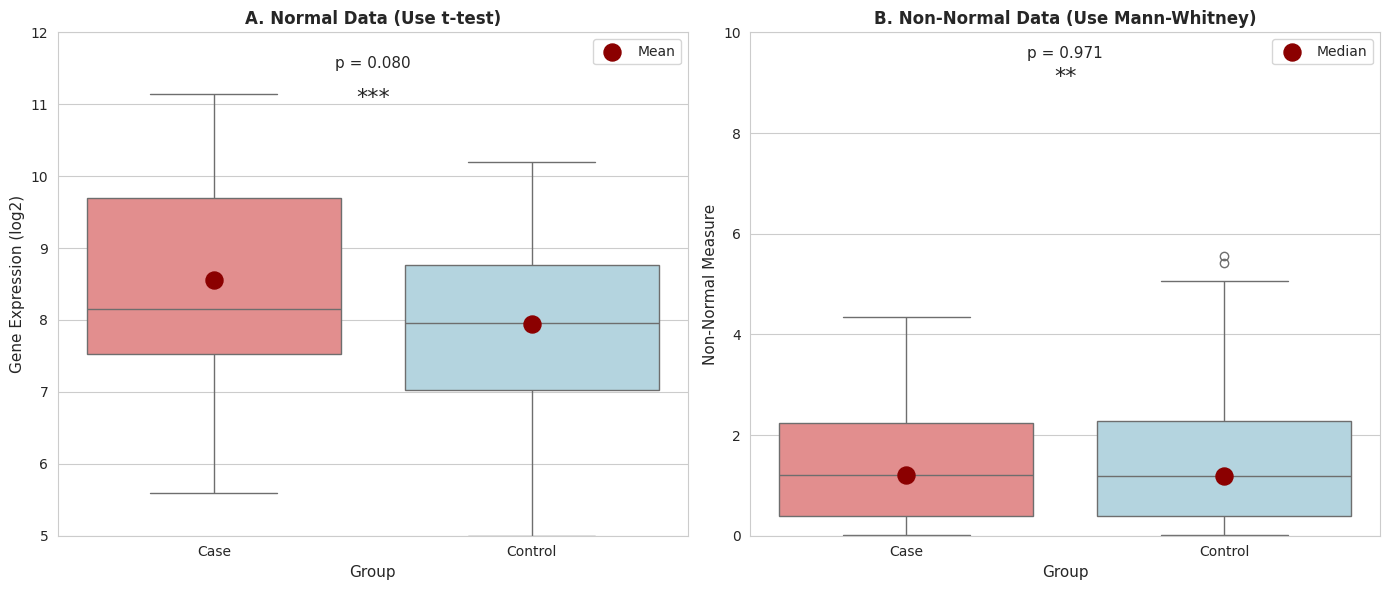

In [ ]:
# Create publication-ready figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel A: Normal data with t-test
sns.boxplot(x='group', y='expression', data=data, ax=axes[0],
            palette={'Case': 'lightcoral', 'Control': 'lightblue'})
means = data.groupby('group')['expression'].mean()
axes[0].scatter([0, 1], means, color='darkred', s=150, zorder=3, label='Mean')
axes[0].set_title('A. Normal Data (Use t-test)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Gene Expression (log2)', fontsize=11)
axes[0].set_xlabel('Group', fontsize=11)
axes[0].set_ylim(5, 12)
axes[0].text(0.5, 11.5, f'p = {p_value:.3f}', ha='center', fontsize=11)
axes[0].text(0.5, 11, '***', ha='center', fontsize=16)
axes[0].legend()

# Panel B: Non-normal data with Mann-Whitney
box_data_nn = pd.DataFrame({
    'value': np.concatenate([nonnormal_case, nonnormal_control]),
    'group': ['Case']*30 + ['Control']*30
})
sns.boxplot(x='group', y='value', data=box_data_nn, ax=axes[1],
            palette={'Case': 'lightcoral', 'Control': 'lightblue'})
medians = box_data_nn.groupby('group')['value'].median()
axes[1].scatter([0, 1], medians, color='darkred', s=150, zorder=3, label='Median')
axes[1].set_title('B. Non-Normal Data (Use Mann-Whitney)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Non-Normal Measure', fontsize=11)
axes[1].set_xlabel('Group', fontsize=11)
axes[1].set_ylim(0, 10)
axes[1].text(0.5, 9.5, f'p = {p_value_mw:.3f}', ha='center', fontsize=11)
axes[1].text(0.5, 9, '**', ha='center', fontsize=16)
axes[1].legend()

plt.tight_layout()
plt.show()

---

## Summary: Decision Guide

### Step-by-step workflow:

```
1. VISUALIZE YOUR DATA
   ├─ Boxplot: Compare distributions
   ├─ Histogram: Check shape
   └─ Q-Q plot: Assess normality

2. CHECK NORMALITY
   ├─ Visual: Q-Q plot
   └─ Statistical: Shapiro-Wilk test

3. CHOOSE TEST
   ├─ Normal data → t-test (parametric)
   │   • Compares means
   │   • Reports t-statistic and p-value
   │   • Calculate Cohen's d for effect size
   │
   └─ Non-normal data → Mann-Whitney (non-parametric)
       • Compares distributions (medians)
       • Reports U-statistic and p-value
       • Robust to outliers

4. INTERPRET RESULTS
   ├─ Statistic: Measure of difference
   ├─ P-value: Hypothesis test result
   └─ Effect size: Magnitude of difference
```

### Quick Reference Table

| Aspect | T-Test (Parametric) | Mann-Whitney (Non-Parametric) |
|--------|---------------------|-------------------------------|
| **Assumption** | Normal distribution | None (distribution-free) |
| **Compares** | Means | Distributions (medians) |
| **Statistic** | t-statistic | U statistic |
| **Sensitive to** | Outliers | - |
| **Power** | Higher (when normal) | Lower (but still good) |
| **Use when** | Data is normal | Data is non-normal |
| **Python function** | `ttest_ind()` | `mannwhitneyu()` |

### Key Takeaways

✓ **Always visualize first** - plots reveal patterns statistics might miss

✓ **Check assumptions** - using the wrong test gives wrong results

✓ **Understand the concepts:**
  - **Statistic:** Numerical measure from your data
  - **P-value:** Result of hypothesis testing (frequentist approach)
  - **Effect size:** Magnitude of difference (biological importance)

✓ **Parametric vs Non-parametric:**
  - Parametric tests assume specific distributions (e.g., normal)
  - Non-parametric tests work with any distribution

✓ **Statistical significance ≠ Biological importance**

**Note:** Multiple testing correction (FDR) is a separate topic covered in Chapter 11!

---

## Practice Exercise

**Scenario:** You measured protein expression in tumor vs normal tissue.

**Tasks:**
1. Generate data (tumor: mean=10, normal: mean=7, sd=2, n=25 each)
2. Create all three visualizations (boxplot, histogram, Q-Q plot)
3. Test for normality
4. Choose and perform appropriate test
5. Interpret results in biological terms

In [ ]:
# YOUR CODE HERE
# Hint: Follow the workflow above

# 1. Generate data
np.random.seed(789)
# tumor_protein = ...
# normal_protein = ...

# 2. Visualizations

# 3. Normality test

# 4. Statistical test

# 5. Interpretation


---

## References

- Student (1908). "The Probable Error of a Mean." Biometrika 6(1): 1-25
- Mann & Whitney (1947). "On a Test of Whether one of Two Random Variables is Stochastically Larger than the Other." Annals of Mathematical Statistics 18(1): 50-60
- Shapiro & Wilk (1965). "An Analysis of Variance Test for Normality." Biometrika 52(3-4): 591-611
- Cohen, J. (1988). Statistical Power Analysis for the Behavioral Sciences. 2nd ed.